In [57]:
import torch
from dataset import CrossingDataset, collate_fn
from model import MultiTaskNet
from loss import SoftDeltaLoss
from torch.utils.data import DataLoader
import numpy as np 
import pandas as pd

In [65]:
df = pd.read_csv('./eval_results.csv')
print(df.columns)

columns_main = ['encoder', 'loss', 'teacher', 'weight', 
                    'RMSE', 'RMSE_log', 'AbsRel', 'SqRel', 'delta1', 'delta2', 'delta3', 
                    'mean_iou', 'light_acc', 'kpt_dist',
                    'params_M', 'size_MB', 'GFLOPs', 'latency_ms', 'FPS']

columns_range = ['encoder', '0-5m_RMSE', '0-5m_delta1', '0-5m_delta2', '0-5m_delta3', '0-5m_AbsRel', 
                    '5-10m_RMSE', '5-10m_delta1', '5-10m_delta2', '5-10m_delta3', '5-10m_AbsRel',
                    '10-20m_RMSE', '10-20m_delta1', '10-20m_delta2', '10-20m_delta3', '10-20m_AbsRel']

Index(['encoder', 'loss', 'teacher', 'weight', 'RMSE', 'RMSE_log', 'AbsRel',
       'SqRel', 'delta1', 'delta2', 'delta3', '0-5m_RMSE', '0-5m_delta1',
       '0-5m_delta2', '0-5m_delta3', '0-5m_AbsRel', '5-10m_RMSE',
       '5-10m_delta1', '5-10m_delta2', '5-10m_delta3', '5-10m_AbsRel',
       '10-20m_RMSE', '10-20m_delta1', '10-20m_delta2', '10-20m_delta3',
       '10-20m_AbsRel', 'mean_iou', 'light_acc', 'kpt_dist', 'params_M',
       'size_MB', 'GFLOPs', 'latency_ms', 'FPS'],
      dtype='object')


In [66]:
df[columns_main].sort_values(by='delta1', ascending=False)

,encoder,loss,teacher,weight,RMSE,RMSE_log,AbsRel,SqRel,delta1,delta2,delta3,mean_iou,light_acc,kpt_dist,params_M,size_MB,GFLOPs,latency_ms,FPS
22,resnet10t,softdelta,False,NaN,2.646409,0.474029,0.242298,0.860054,0.739066,0.893312,0.932751,0.420015,0.899497,0.174783,7.604017,29.073515,13.769733,2.250266,444.391893
6,efficientnet_b3,softdelta,False,NaN,2.600053,0.463948,0.239530,0.811897,0.737970,0.888203,0.933030,0.529137,0.914573,0.128628,12.320737,47.536966,11.127063,11.500061,86.956064
1,efficientnet_b0,softdelta,False,NaN,2.639033,0.470540,0.237081,0.812178,0.736744,0.891028,0.932345,0.562011,0.899497,0.121265,5.708597,22.067968,7.839430,6.300068,158.728448
7,efficientnet_b3,softdelta,True,0.1,2.423647,0.409516,0.243709,0.788786,0.718917,0.888217,0.943234,0.579982,0.929648,0.114259,12.320737,47.536966,11.127063,10.999990,90.909178
2,efficientnet_b0,softdelta,True,0.1,2.360401,0.408557,0.244580,0.792823,0.718167,0.895057,0.947427,0.570972,0.909548,0.115104,5.708597,22.067968,7.839430,6.449997,155.038822
0,efficientnet_b0,silog,False,NaN,2.765347,0.516016,0.234276,0.860402,0.717017,0.883774,0.924157,0.532800,0.909548,0.121851,5.708597,22.067968,7.839430,6.150019,162.601119
25,resnet18,softdelta,False,NaN,2.590402,0.471767,0.246592,0.850814,0.716415,0.888950,0.937485,0.477840,0.889447,0.154168,13.858041,52.957510,17.515312,3.549933,281.695423
24,resnet18,silog,False,NaN,2.801166,0.515988,0.238917,0.931340,0.716030,0.880277,0.923182,0.457489,0.889447,0.150361,13.858041,52.957510,17.515312,2.650225,377.326430
21,resnet10t,silog,False,NaN,2.783414,0.504028,0.235343,0.834182,0.714938,0.876996,0.922151,0.427017,0.894472,0.176137,7.604017,29.073515,13.769733,2.400196,416.632711
12,mobilenetv3_large_100,softdelta,False,NaN,2.601816,0.473100,0.242639,0.809176,0.706594,0.886557,0.936002,0.467194,0.899497,0.172053,5.412841,20.864042,7.097546,5.799997,172.413887


In [72]:
df[['encoder', 'loss', 'teacher', 'weight', 
        '0-5m_delta1', '5-10m_delta1', '10-20m_delta1', 
        'params_M', 'GFLOPs', 'FPS'
    ]].sort_values(by='5-10m_delta1', ascending=False)

,encoder,loss,teacher,weight,0-5m_delta1,5-10m_delta1,10-20m_delta1,params_M,GFLOPs,FPS
6,efficientnet_b3,softdelta,False,NaN,0.784124,0.756703,0.605387,12.320737,11.127063,86.956064
10,efficientnet_b5,softdelta,True,0.1,0.717702,0.754747,0.584277,29.686249,18.532002,65.574064
9,efficientnet_b5,softdelta,False,NaN,0.739297,0.754109,0.566635,29.686249,18.532002,53.050385
22,resnet10t,softdelta,False,NaN,0.790521,0.746695,0.611353,7.604017,13.769733,444.391893
25,resnet18,softdelta,False,NaN,0.750201,0.737948,0.624756,13.858041,17.515312,281.695423
1,efficientnet_b0,softdelta,False,NaN,0.790724,0.737539,0.609555,5.708597,7.839430,158.728448
12,mobilenetv3_large_100,softdelta,False,NaN,0.740438,0.736025,0.606218,5.412841,7.097546,172.413887
7,efficientnet_b3,softdelta,True,0.1,0.765629,0.731945,0.604009,12.320737,11.127063,90.909178
16,mobilenetv4_conv_small,softdelta,False,NaN,0.744754,0.730710,0.568454,3.702553,7.399799,170.940717
20,regnety_002,softdelta,False,NaN,0.730443,0.729190,0.583941,5.046981,7.451262,149.253927


## SI-Log vs SoftDeltaLoss

In [60]:
df[df['loss'] == 'silog'][columns_main].sort_values(by='delta1', ascending=False)

,encoder,loss,teacher,weight,RMSE,RMSE_log,AbsRel,SqRel,delta1,delta2,delta3,mean_iou,light_acc,kpt_dist,params_M,size_MB,GFLOPs,latency_ms,FPS
0,efficientnet_b0,silog,False,NaN,2.765347,0.516016,0.234276,0.860402,0.717017,0.883774,0.924157,0.532800,0.909548,0.121851,5.708597,22.067968,7.839430,6.150019,162.601119
24,resnet18,silog,False,NaN,2.801166,0.515988,0.238917,0.931340,0.716030,0.880277,0.923182,0.457489,0.889447,0.150361,13.858041,52.957510,17.515312,2.650225,377.326430
21,resnet10t,silog,False,NaN,2.783414,0.504028,0.235343,0.834182,0.714938,0.876996,0.922151,0.427017,0.894472,0.176137,7.604017,29.073515,13.769733,2.400196,416.632711
11,mobilenetv3_large_100,silog,False,NaN,2.790740,0.517749,0.262812,1.050976,0.706552,0.871845,0.922645,0.475879,0.899497,0.155917,5.412841,20.864042,7.097546,5.999982,166.667157
5,efficientnet_b3,silog,False,NaN,2.691877,0.484950,0.232388,0.781961,0.703006,0.878017,0.926747,0.531646,0.934673,0.130226,12.320737,47.536966,11.127063,9.750199,102.562006
19,regnety_002,silog,False,NaN,2.849772,0.531685,0.241365,0.861340,0.685616,0.863909,0.915279,0.482569,0.884422,0.159636,5.046981,19.458815,7.451262,7.649982,130.719262
17,regnetx_002,silog,False,NaN,2.922579,0.527048,0.228207,0.810815,0.677988,0.863948,0.916078,0.475079,0.904523,0.154172,4.568777,17.616232,7.450313,6.100023,163.933814
15,mobilenetv4_conv_small,silog,False,NaN,3.015434,0.563984,0.274054,1.168686,0.674267,0.845374,0.906463,0.492014,0.869347,0.157099,3.702553,14.326410,7.399799,6.400049,156.248810
8,efficientnet_b5,silog,False,NaN,2.947018,0.545994,0.251611,0.933350,0.668292,0.858059,0.910018,0.582973,0.879397,0.126019,29.686249,114.204218,18.532002,18.450010,54.200513
13,mobilenetv3_small_100,silog,False,NaN,3.164658,0.582974,0.294489,1.374096,0.647214,0.836111,0.896396,0.480800,0.879397,0.174841,3.000793,11.593023,5.941818,5.100107,196.074310


In [61]:
df[df['loss'] == 'softdelta'][columns_main].sort_values(by='delta1', ascending=False)

,encoder,loss,teacher,weight,RMSE,RMSE_log,AbsRel,SqRel,delta1,delta2,delta3,mean_iou,light_acc,kpt_dist,params_M,size_MB,GFLOPs,latency_ms,FPS
22,resnet10t,softdelta,False,NaN,2.646409,0.474029,0.242298,0.860054,0.739066,0.893312,0.932751,0.420015,0.899497,0.174783,7.604017,29.073515,13.769733,2.250266,444.391893
6,efficientnet_b3,softdelta,False,NaN,2.600053,0.463948,0.239530,0.811897,0.737970,0.888203,0.933030,0.529137,0.914573,0.128628,12.320737,47.536966,11.127063,11.500061,86.956064
1,efficientnet_b0,softdelta,False,NaN,2.639033,0.470540,0.237081,0.812178,0.736744,0.891028,0.932345,0.562011,0.899497,0.121265,5.708597,22.067968,7.839430,6.300068,158.728448
7,efficientnet_b3,softdelta,True,0.1,2.423647,0.409516,0.243709,0.788786,0.718917,0.888217,0.943234,0.579982,0.929648,0.114259,12.320737,47.536966,11.127063,10.999990,90.909178
2,efficientnet_b0,softdelta,True,0.1,2.360401,0.408557,0.244580,0.792823,0.718167,0.895057,0.947427,0.570972,0.909548,0.115104,5.708597,22.067968,7.839430,6.449997,155.038822
25,resnet18,softdelta,False,NaN,2.590402,0.471767,0.246592,0.850814,0.716415,0.888950,0.937485,0.477840,0.889447,0.154168,13.858041,52.957510,17.515312,3.549933,281.695423
12,mobilenetv3_large_100,softdelta,False,NaN,2.601816,0.473100,0.242639,0.809176,0.706594,0.886557,0.936002,0.467194,0.899497,0.172053,5.412841,20.864042,7.097546,5.799997,172.413887
3,efficientnet_b0,softdelta,True,0.3,2.284710,0.394244,0.246753,0.707810,0.706437,0.900643,0.947604,0.554045,0.894472,0.119975,5.708597,22.067968,7.839430,6.049955,165.290489
9,efficientnet_b5,softdelta,False,NaN,2.696831,0.475910,0.249365,0.852526,0.705090,0.876929,0.928523,0.555976,0.899497,0.132449,29.686249,114.204218,18.532002,18.850005,53.050385
16,mobilenetv4_conv_small,softdelta,False,NaN,2.737757,0.498945,0.298187,1.277261,0.703521,0.874317,0.926985,0.508613,0.889447,0.143287,3.702553,14.326410,7.399799,5.849981,170.940717


In [62]:
tmp_df_silog = df[df['loss'] == 'silog'][columns_main]
tmp_df_softdelta = df[df['loss'] == 'softdelta'][columns_main]

encoder_name = tmp_df_silog['encoder'].unique()

In [52]:
LOWER_IS_BETTER = {"RMSE", "RMSE_log", "AbsRel", "SqRel"}

def get_value(df, encoder, loss, metric):
    """Return the metric value for one (encoder, loss), or np.nan if missing."""
    row = df[(df["encoder"] == encoder) & (df["loss"] == loss) & (df['teacher'] == False)]
    if row.empty:
        return np.nan
    return float(row[metric].iloc[0])

def plot_loss_comparison(df, models, metric, losses=["silog", "softdelta"], min_ylim=0.5):
    import matplotlib.pyplot as plt
    
    x = np.arange(len(models))
    n = len(losses)
    width = 0.8 / n                      # total group width 0.8

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=(max(7, len(models) * 1.3), 5))
    for i, loss in enumerate(losses):
        vals = [get_value(df, m, loss, metric) for m in models]
        offset = (i - (n - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=loss,
                        color=colors[i % len(colors)], edgecolor="black",
                        linewidth=0.5)
        # value labels on top of each bar
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, v,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    better = "lower is better" if metric in LOWER_IS_BETTER else "higher is better"
    ax.set_xlabel("Encoder")
    ax.set_ylabel(f"{metric}  ({better})")
    ax.set_title(f"{metric} by encoder: {' vs '.join(losses)} | No Teacher")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.legend(title="loss")
    ax.grid(axis="y", alpha=0.3)
    # give headroom for the value labels
    valid = [get_value(df, m, l, metric) for m in models for l in losses]
    valid = [v for v in valid if not np.isnan(v)]
    
    if valid:
        ax.set_ylim(min_ylim, max(valid) * 1.15)
    fig.tight_layout()
    
    return fig, ax

(<Figure size 1300x500 with 1 Axes>,
 <Axes: title={'center': 'delta1 by encoder: silog vs softdelta | No Teacher'}, xlabel='Encoder', ylabel='delta1  (higher is better)'>)

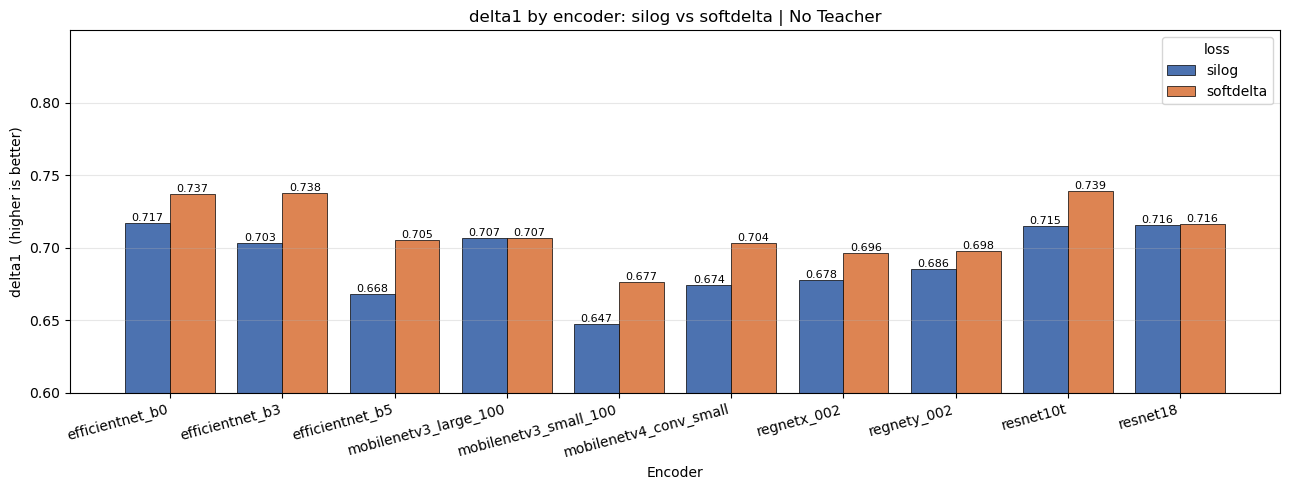

In [54]:
plot_loss_comparison(df, encoder_name, "delta1", min_ylim=0.6)

(<Figure size 1300x500 with 1 Axes>,
 <Axes: title={'center': 'RMSE by encoder: silog vs softdelta | No Teacher'}, xlabel='Encoder', ylabel='RMSE  (lower is better)'>)

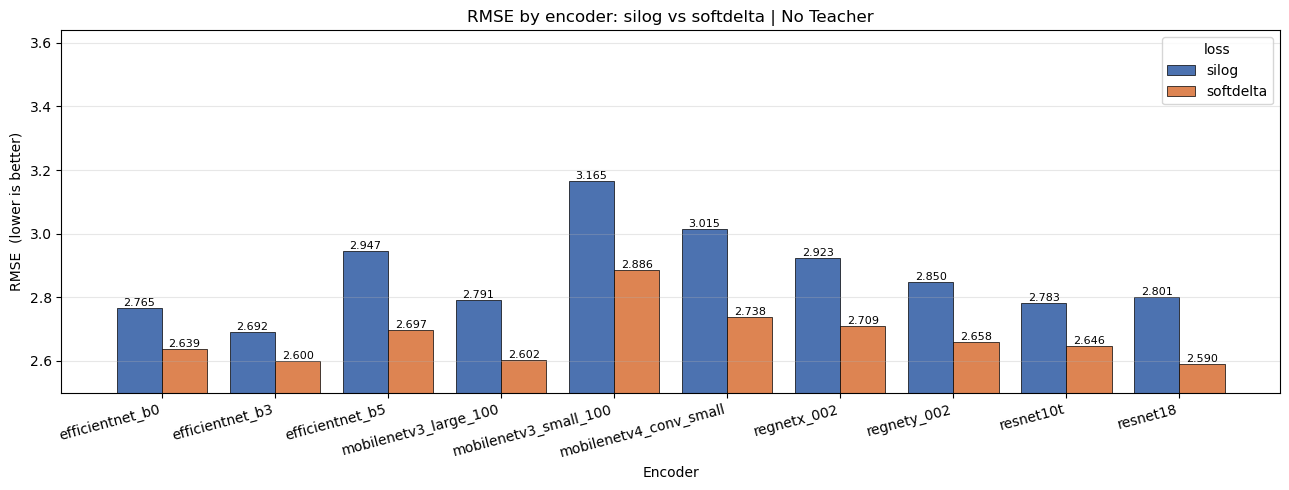

In [56]:
plot_loss_comparison(df, encoder_name, "RMSE", min_ylim=2.5)

## Teacher's Impact - Hole Filling Strategy

## Teacher's Impact - Train 2 phase

## Zone Evaluation

## Multi-task lain: Deteksi, Keypoint, Light

## Qualitative Evaluation